In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns



In [2]:
# Generate a synthetic 3D dataset
np.random.seed(42)
n_samples = 300

# Class 0: clustered around origin, but one feature has a wider range
X0 = np.random.rand(n_samples // 2, 3) * 10
X0[:, 0] = X0[:, 0] * 0.1 # Make first feature smaller range
Y0 = np.zeros(n_samples // 2)

# Class 1: shifted, with one feature also having a wider range
X1 = np.random.rand(n_samples // 2, 3) * 10 + 5
X1[:, 0] = X1[:, 0] * 0.1 + 1 # Make first feature smaller range, shifted
Y1 = np.ones(n_samples // 2)

X = np.vstack((X0, X1))
y = np.hstack((Y0, Y1))

df = pd.DataFrame(X, columns=['feature_x', 'feature_y', 'feature_z'])
df['target'] = y

print("Original Dataset Head:")
display(df.head())

print("Original Feature Ranges:")
for col in ['feature_x', 'feature_y', 'feature_z']:
    print(f"{col}: Min={df[col].min():.2f}, Max={df[col].max():.2f}")

Original Dataset Head:


,feature_x,feature_y,feature_z,target
0,0.374540,9.507143,7.319939,0.0
1,0.598658,1.560186,1.559945,0.0
2,0.058084,8.661761,6.011150,0.0
3,0.708073,0.205845,9.699099,0.0
4,0.832443,2.123391,1.818250,0.0


Original Feature Ranges:
feature_x: Min=0.01, Max=2.50
feature_y: Min=0.05, Max=14.97
feature_z: Min=0.07, Max=14.87


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)
print(f"KNN Accuracy without scaling: {accuracy_unscaled:.4f}")

KNN Accuracy without scaling: 0.9889


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

df_scaled = pd.DataFrame(X_train_scaled, columns=['feature_x_scaled', 'feature_y_scaled', 'feature_z_scaled'])
print("Scaled Training Data Head:")
display(df_scaled.head())

print("Scaled Feature Ranges (approx):")
for col in df_scaled.columns:
    print(f"{col}: Mean={df_scaled[col].mean():.2f}, Std={df_scaled[col].std():.2f}")

Scaled Training Data Head:


,feature_x_scaled,feature_y_scaled,feature_z_scaled
0,0.866380,0.253717,1.031239
1,-0.843626,-0.014656,0.626840
2,-0.882743,-1.888754,-1.617532
3,0.346025,0.765470,0.458829
4,-1.444516,0.517609,0.196304


Scaled Feature Ranges (approx):
feature_x_scaled: Mean=-0.00, Std=1.00
feature_y_scaled: Mean=-0.00, Std=1.00
feature_z_scaled: Mean=0.00, Std=1.00


In [6]:
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"KNN Accuracy with scaling: {accuracy_scaled:.4f}")

KNN Accuracy with scaling: 1.0000



--- Summary ---
Accuracy without scaling: 0.9889
Accuracy with scaling: 1.0000


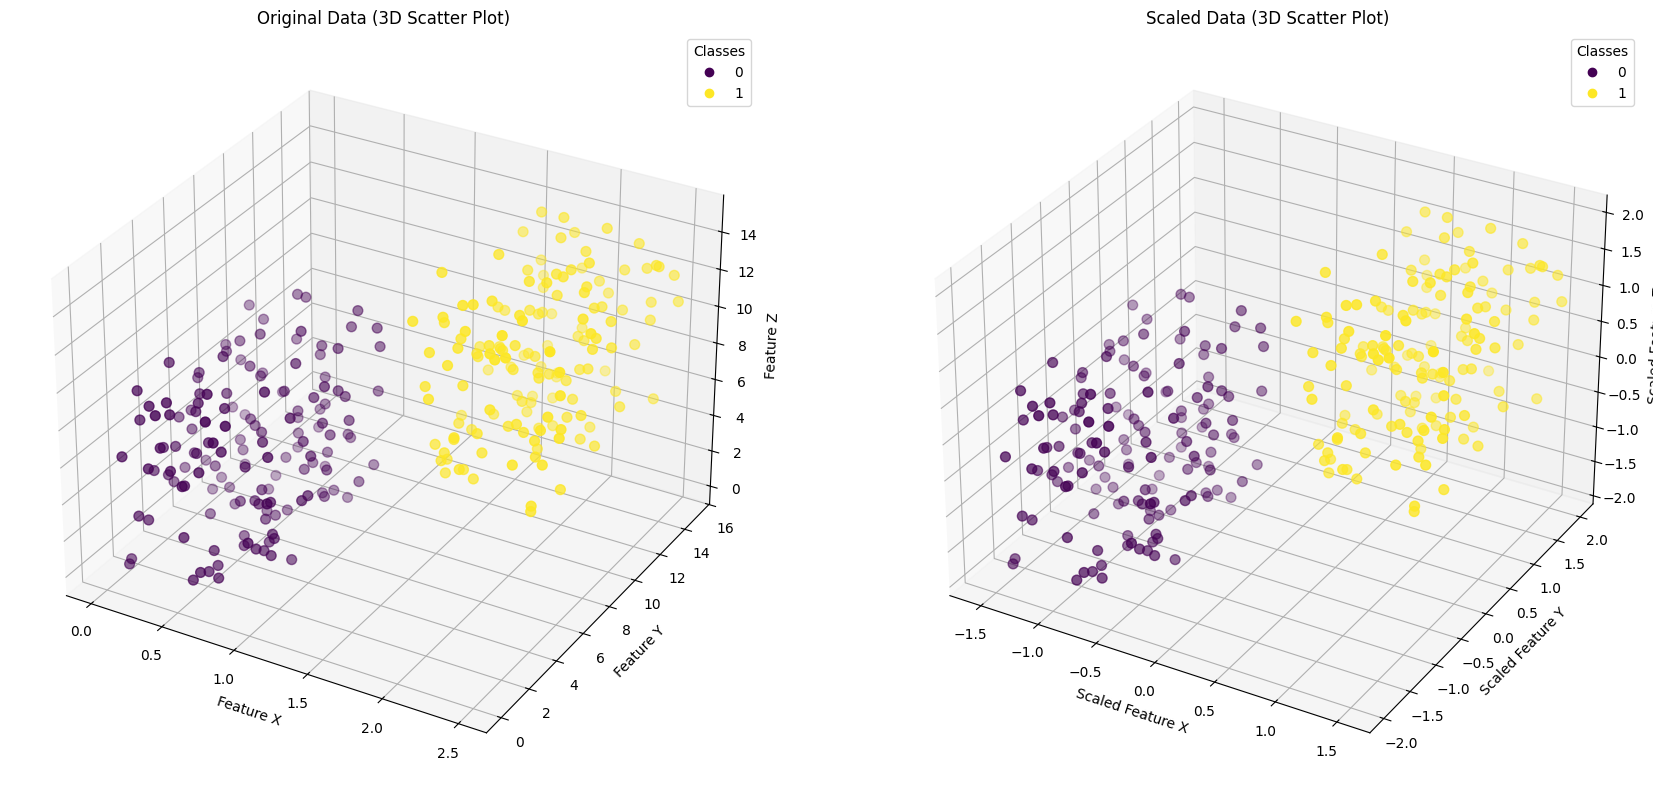

In [7]:
print("\n--- Summary ---")
print(f"Accuracy without scaling: {accuracy_unscaled:.4f}")
print(f"Accuracy with scaling: {accuracy_scaled:.4f}")

fig = plt.figure(figsize=(18, 8))

# Plot original data
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', s=50)
ax1.set_title('Original Data (3D Scatter Plot)')
ax1.set_xlabel('Feature X')
ax1.set_ylabel('Feature Y')
ax1.set_zlabel('Feature Z')
ax1.legend(*scatter1.legend_elements(), title="Classes")

# Plot scaled data (using full scaled dataset for visualization)
X_scaled_full = scaler.fit_transform(X)
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_scaled_full[:, 0], X_scaled_full[:, 1], X_scaled_full[:, 2], c=y, cmap='viridis', s=50)
ax2.set_title('Scaled Data (3D Scatter Plot)')
ax2.set_xlabel('Scaled Feature X')
ax2.set_ylabel('Scaled Feature Y')
ax2.set_zlabel('Scaled Feature Z')
ax2.legend(*scatter2.legend_elements(), title="Classes")

plt.tight_layout()
plt.show()